In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             silhouette_score)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Data

In [35]:
seed = 42

df = pd.read_csv('Dataset.csv')

X = df.drop(['46'], axis=1)
y = df['46']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_full_scaled = scaler.fit_transform(X)

labelencoder = LabelEncoder()
y_encoded = labelencoder.fit_transform(y)

In [36]:
pca = PCA(n_components=46)
X1 = pca.fit_transform(X)

# Classification

-------------------------------------------------
Logistic Regression
              precision    recall  f1-score   support

      German       1.00      1.00      1.00        36
     Italian       1.00      1.00      1.00        36
      Korean       1.00      1.00      1.00        36
     Spanish       1.00      1.00      1.00        36

    accuracy                           1.00       144
   macro avg       1.00      1.00      1.00       144
weighted avg       1.00      1.00      1.00       144

-------------------------------------------------
SVM (RBF Kernel)
              precision    recall  f1-score   support

      German       1.00      1.00      1.00        36
     Italian       1.00      1.00      1.00        36
      Korean       1.00      1.00      1.00        36
     Spanish       1.00      1.00      1.00        36

    accuracy                           1.00       144
   macro avg       1.00      1.00      1.00       144
weighted avg       1.00      1.00      1.00     

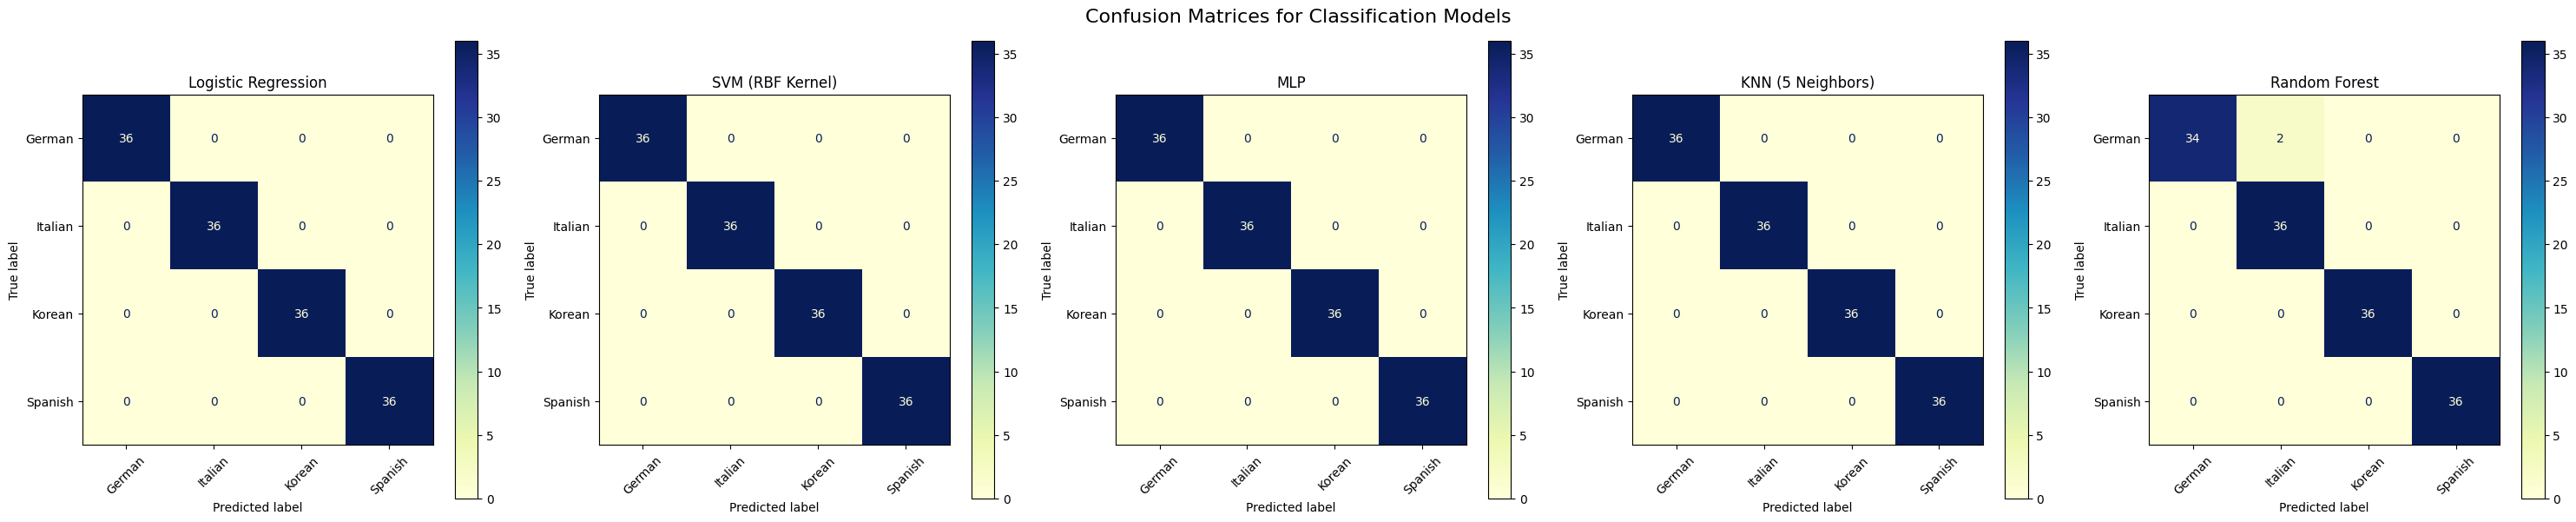

In [37]:
models = {
    'Logistic Regression': LogisticRegression(random_state=seed, max_iter=1000),
    'SVM (RBF Kernel)': SVC(kernel='rbf', random_state=seed),
    'MLP': MLPClassifier(hidden_layer_sizes=(50,), activation='relu', max_iter=300, random_state=seed),
    'KNN (5 Neighbors)' : KNeighborsClassifier(n_neighbors=5),
    'Random Forest' : RandomForestClassifier(n_estimators=50, random_state=seed)
}

results_data = []

fig, axes = plt.subplots(1, 5, figsize=(30, 6))
fig.suptitle('Confusion Matrices for Classification Models', fontsize=16)

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results_data.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    print('-------------------------------------------------')
    print(f'{name}')
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(ax=axes[idx], cmap='YlGnBu', xticks_rotation=45)
    axes[idx].set_title(name)
    axes[idx].grid(False)

plt.tight_layout()
plt.show()


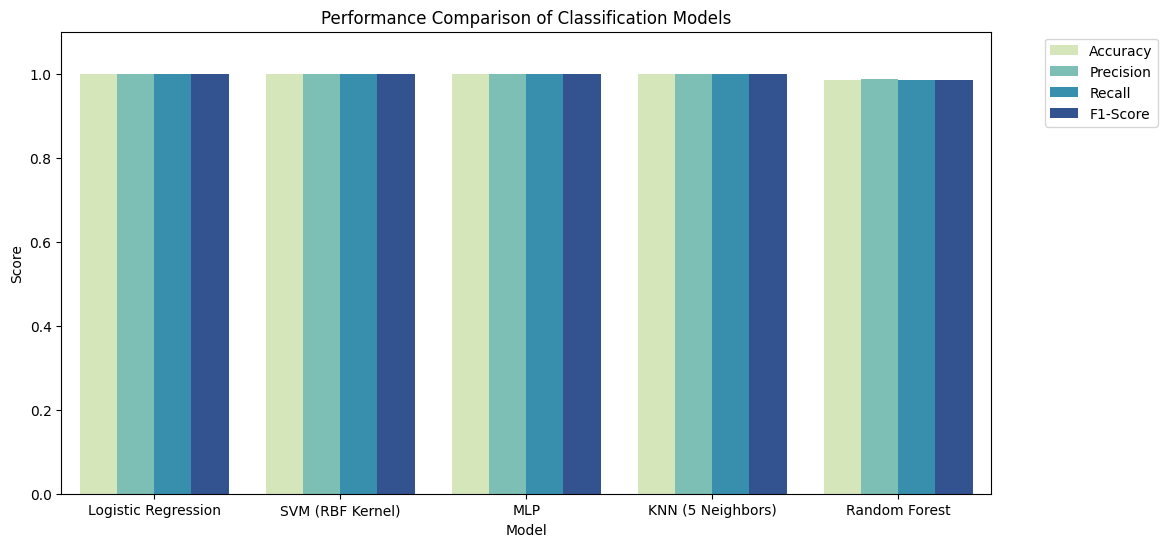

In [38]:
results_df = pd.DataFrame(results_data)

results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='YlGnBu')
plt.title('Performance Comparison of Classification Models')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


# Clustering

In [39]:
def calculate_purity(y_true, y_pred):
    cont_matrix = pd.crosstab(y_true, y_pred)
    return np.sum(cont_matrix.max(axis=0)) / np.sum(cont_matrix.sum())

## K-Mean

Silhouette Score for K-Means (k=6): 0.2873


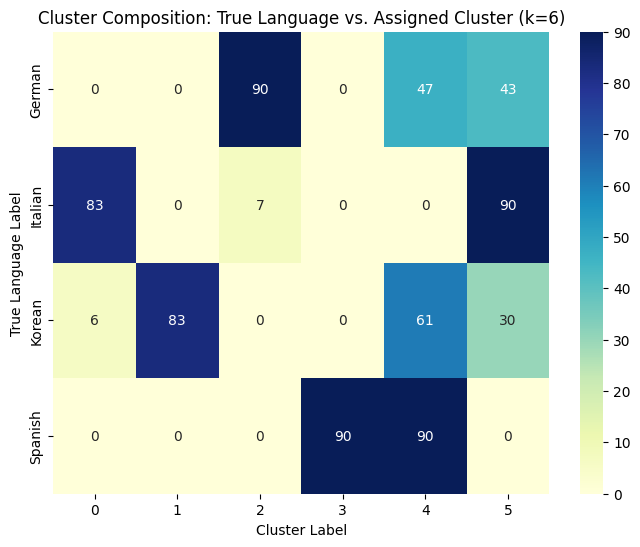

Cluster Purity Score: 0.7306
Interpretation: 73.06% of the data points belong to the dominant language of their respective clusters.


In [ ]:
k_eval = 6

kmeans = KMeans(n_clusters=k_eval, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_full_scaled)

sil_score = silhouette_score(X_full_scaled, cluster_labels)
print(f'Silhouette Score for K-Means (k={k_eval}): {sil_score:.4f}')

comparison_df = pd.DataFrame({'True Language': y, 'Cluster': cluster_labels})

contingency_matrix = pd.crosstab(comparison_df['True Language'], comparison_df['Cluster'])

plt.figure(figsize=(8, 6))
sns.heatmap(contingency_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Cluster Composition: True Language vs. Assigned Cluster (k={k_eval})')
plt.ylabel('True Language Label')
plt.xlabel('Cluster Label')
plt.show()

purity = calculate_purity(y_encoded, cluster_labels)
print(f'Cluster Purity Score: {purity:.4f}')
print(f'Interpretation: {purity*100:.2f}% of the data points belong to the dominant language of their respective clusters.')

## Hierarchical

Silhouette Score for Hierarchical: 0.2782


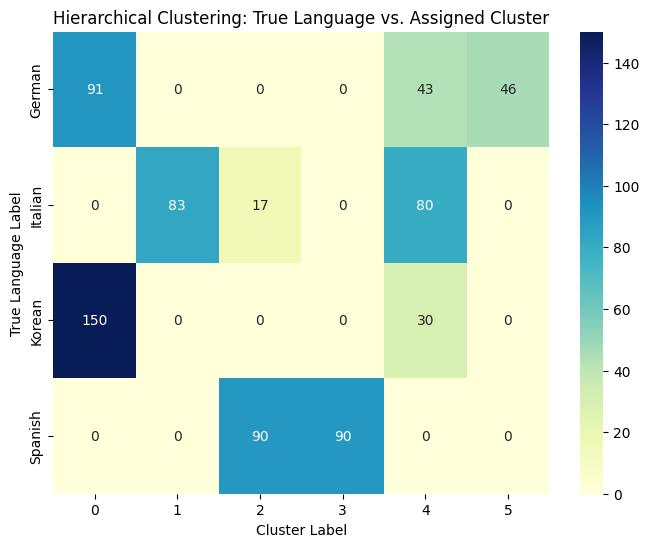

Hierarchical Cluster Purity Score: 0.7486


In [9]:
hc = AgglomerativeClustering(n_clusters=6, linkage='ward')
hc_labels = hc.fit_predict(X_full_scaled)

sil_score_hc = silhouette_score(X_full_scaled, hc_labels)
print(f'Silhouette Score for Hierarchical: {sil_score_hc:.4f}')

hc_df = pd.DataFrame({'True Language': y, 'Cluster': hc_labels})
hc_contingency = pd.crosstab(hc_df['True Language'], hc_df['Cluster'])

plt.figure(figsize=(8, 6))
sns.heatmap(hc_contingency, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'Hierarchical Clustering: True Language vs. Assigned Cluster')
plt.ylabel('True Language Label')
plt.xlabel('Cluster Label')
plt.show()

purity_hc = calculate_purity(y_encoded, hc_labels)
print(f'Hierarchical Cluster Purity Score: {purity_hc:.4f}')

## GMM

Silhouette Score for GMM: 0.2470


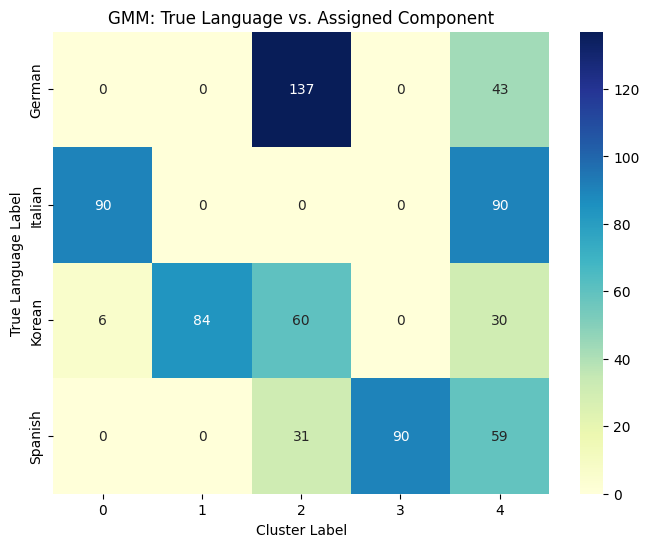

GMM Cluster Purity Score: 0.6819


In [ ]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_full_scaled)

sil_score_gmm = silhouette_score(X_full_scaled, gmm_labels)
print(f'Silhouette Score for GMM: {sil_score_gmm:.4f}')

gmm_df = pd.DataFrame({'True Language': y, 'Cluster': gmm_labels})
gmm_contingency = pd.crosstab(gmm_df['True Language'], gmm_df['Cluster'])

plt.figure(figsize=(8, 6))
sns.heatmap(gmm_contingency, annot=True, fmt='d', cmap='YlGnBu')
plt.title(f'GMM: True Language vs. Assigned Component')
plt.ylabel('True Language Label')
plt.xlabel('Cluster Label')
plt.show()

purity_gmm = calculate_purity(y_encoded, gmm_labels)
print(f'GMM Cluster Purity Score: {purity_gmm:.4f}')


## DBSCAN

Silhouette Score for DBSCAN: 0.2551


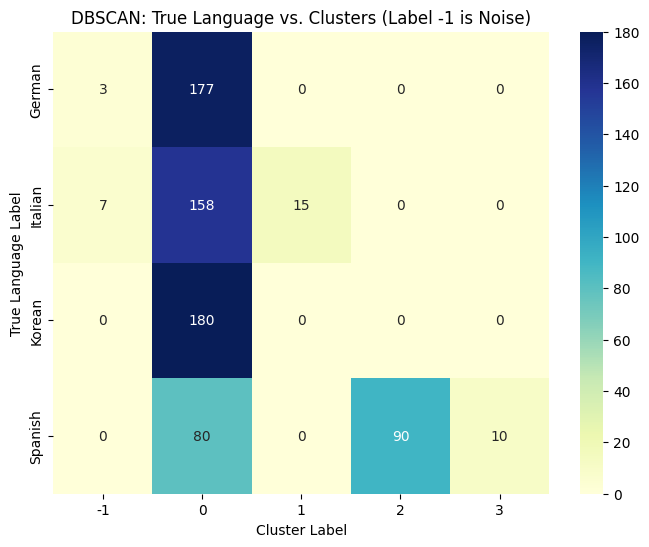

DBSCAN Cluster Purity Score: 0.4194
Percentage of data considered Noise (-1): 1.39%


In [41]:
eps = 6.677
min_samples = 10

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_full_scaled)

unique_labels = set(db_labels)
if len(unique_labels) > 1:
    sil_score_db = silhouette_score(X_full_scaled, db_labels)
    print(f'Silhouette Score for DBSCAN: {sil_score_db:.4f}')
    
    db_df = pd.DataFrame({'True Language': y, 'Cluster': db_labels})
    db_contingency = pd.crosstab(db_df['True Language'], db_df['Cluster'])

    plt.figure(figsize=(8, 6))
    sns.heatmap(db_contingency, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f'DBSCAN: True Language vs. Clusters (Label -1 is Noise)')
    plt.ylabel('True Language Label')
    plt.xlabel('Cluster Label')
    plt.show()

    purity_db = calculate_purity(y_encoded, db_labels)
    print(f'DBSCAN Cluster Purity Score: {purity_db:.4f}')
    
    noise_percent = list(db_labels).count(-1) / len(db_labels) * 100
    print(f'Percentage of data considered Noise (-1): {noise_percent:.2f}%')

else:
    print('DBSCAN failed to find distinct clusters with current parameters.')


## Compare Results

In [ ]:
def calculate_purity(y_true, y_pred):
    cont_matrix = pd.crosstab(y_true, y_pred)
    return np.sum(cont_matrix.max(axis=0)) / np.sum(cont_matrix.sum())

def evaluate_clustering(model_name, model_instance, X, y_true):

    y_pred = model_instance.fit_predict(X)
    
    if len(set(y_pred)) <= 1:
        print(f'Warning: {model_name} found only 1 cluster/noise. Metrics may be invalid.')
        return None

    sil = silhouette_score(X, y_pred)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    purity = calculate_purity(y_true, y_pred)
    
    
    return {'Model': model_name, 'Silhouette': sil, 'ARI': ari, 'NMI': nmi, 'Purity': purity}

kmeans = KMeans(n_clusters=6, random_state=42)
hc = AgglomerativeClustering(n_clusters=6, linkage='ward')
gmm = GaussianMixture(n_components=5, random_state=42)
dbscan = DBSCAN(eps=6.677, min_samples=10)

results = []
models = [
    ('K-Means', kmeans),
    ('Hierarchical', hc),
    ('GMM', gmm),
    ('DBSCAN', dbscan)
]

for name, model in models:
    res = evaluate_clustering(name, model, X_full_scaled, y)
    if res:
        results.append(res)

results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)


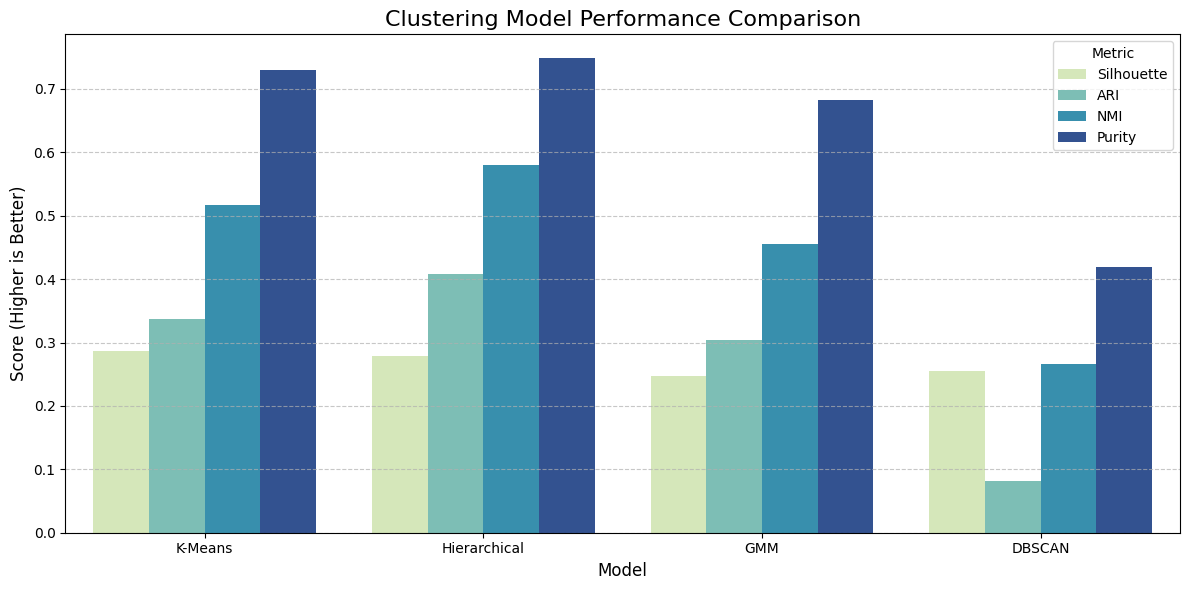

In [43]:
results_melted = results_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 6))
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', palette='YlGnBu')

plt.title('Clustering Model Performance Comparison', fontsize=16)
plt.ylabel('Score (Higher is Better)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Metric', loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()

plt.show()